# Analysis Notebook — Minggu 9 Hari Rabu: Data-Driven Recommendation
**Business Problem (dari Hari Senin):** 87 kota mengalami penurunan penjualan meski total penjualan
perusahaan naik 42,7%, terkonsentrasi di Kota Dover, Madison, dan Phoenix, disebabkan oleh hilangnya
jumlah pesanan/pelanggan aktif.

Notebook ini menyusun **3 rekomendasi berbasis data** mengikuti alur:
**Evidence → Analysis → Insight → Recommendation**

Bisa dijalankan langsung di Google Colab — upload `SalesInsight_Database.xlsx` saat diminta.

In [1]:
FILE = 'SalesInsight_Database.xlsx'
try:
    import google.colab
    from google.colab import files
    import os
    if not os.path.exists(FILE):
        print("Silakan upload file 'SalesInsight_Database.xlsx':")
        uploaded = files.upload()
        FILE = list(uploaded.keys())[0]
except ImportError:
    print("Dijalankan di luar Google Colab. Pastikan file", FILE, "ada di folder yang sama.")


Dijalankan di luar Google Colab. Pastikan file SalesInsight_Database.xlsx ada di folder yang sama.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

sales = pd.read_excel(FILE, sheet_name='Sales')
products = pd.read_excel(FILE, sheet_name='Products')
customers = pd.read_excel(FILE, sheet_name='Customers')
sales['OrderDate'] = pd.to_datetime(sales['OrderDate'])

df = sales.merge(products[['ProductID', 'Category']], on='ProductID', how='left')
df = df.merge(customers[['CustomerID', 'City', 'Country']], on='CustomerID', how='left')

last3 = df[(df['OrderDate'] >= '2017-10-01') & (df['OrderDate'] <= '2017-12-31')]
prev3 = df[(df['OrderDate'] >= '2017-07-01') & (df['OrderDate'] <= '2017-09-30')]

print('Data siap. Baris Jul-Sep 2017:', len(prev3), '| Baris Okt-Des 2017:', len(last3))

Data siap. Baris Jul-Sep 2017: 903 | Baris Okt-Des 2017: 1219


---
## Rekomendasi 1 — Prioritaskan 31 Kota Teratas, Bukan Seluruh 87 Kota

### Evidence

In [3]:
city_comp = pd.DataFrame({
    'Penjualan_JulSep2017': prev3.groupby('City')['SalesAmount'].sum(),
    'Penjualan_OktDes2017': last3.groupby('City')['SalesAmount'].sum()
}).fillna(0)
city_comp['Selisih'] = city_comp['Penjualan_OktDes2017'] - city_comp['Penjualan_JulSep2017']

declining = city_comp[city_comp['Selisih'] < 0].sort_values('Selisih').copy()
total_loss = declining['Selisih'].sum()
declining['Kontribusi%'] = declining['Selisih'] / total_loss * 100
declining['KontribusiKumulatif%'] = declining['Kontribusi%'].cumsum()

jumlah_kota_menurun = len(declining)
kota_untuk_80persen = (declining['KontribusiKumulatif%'] <= 80).sum() + 1

print(f"Total kota yang menurun         : {jumlah_kota_menurun}")
print(f"Total kerugian gabungan         : ${total_loss:,.2f}")
print(f"Jumlah kota untuk mencapai 80% dari total kerugian: {kota_untuk_80persen} kota")
declining.head(10)[['Selisih', 'Kontribusi%', 'KontribusiKumulatif%']]

Total kota yang menurun         : 87
Total kerugian gabungan         : $-80,108.42
Jumlah kota untuk mencapai 80% dari total kerugian: 31 kota


,Selisih,Kontribusi%,KontribusiKumulatif%
City,,,
Dover,"-8,487.50",10.60,10.60
Madison,"-5,704.43",7.12,17.72
Phoenix,"-4,252.37",5.31,23.02
Mesa,"-4,050.91",5.06,28.08
Chicago,"-2,999.49",3.74,31.83
Manteca,"-2,877.40",3.59,35.42
Lawrence,"-2,528.94",3.16,38.57
Florence,"-2,435.07",3.04,41.61
San Diego,"-2,280.80",2.85,44.46


### Analysis

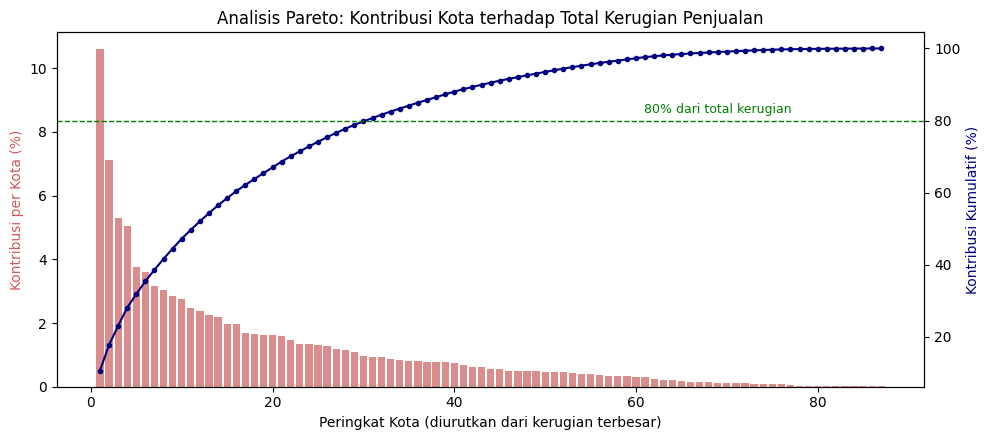

In [4]:
fig, ax1 = plt.subplots(figsize=(10, 4.5))
x = range(1, len(declining) + 1)
ax1.bar(x, declining['Kontribusi%'], color='indianred', alpha=0.7, label='Kontribusi per Kota (%)')
ax1.set_xlabel('Peringkat Kota (diurutkan dari kerugian terbesar)')
ax1.set_ylabel('Kontribusi per Kota (%)', color='indianred')

ax2 = ax1.twinx()
ax2.plot(x, declining['KontribusiKumulatif%'], color='navy', marker='.', label='Kontribusi Kumulatif (%)')
ax2.axhline(80, color='green', linestyle='--', linewidth=1)
ax2.text(len(declining)*0.7, 82, '80% dari total kerugian', color='green', fontsize=9)
ax2.set_ylabel('Kontribusi Kumulatif (%)', color='navy')

plt.title('Analisis Pareto: Kontribusi Kota terhadap Total Kerugian Penjualan')
plt.tight_layout()
plt.savefig('rekomendasi1_pareto.png', dpi=120)
plt.show()

### Insight
Hanya **31 dari 87 kota (sekitar 36%)** yang sudah menyumbang **80% dari
total kerugian penjualan**. Ini adalah pola Pareto klasik: sebagian kecil kota bertanggung jawab atas
sebagian besar masalah. Mencoba memperbaiki seluruh 87 kota sekaligus akan memboroskan sumber daya, padahal
dampak terbesar bisa dicapai dengan fokus ke minoritas kota tersebut.

### Recommendation
**Alokasikan tim reaktivasi pelanggan dan anggaran pemulihan terlebih dahulu ke 31 kota dengan kontribusi
kerugian terbesar**, bukan menyebar upaya secara merata ke semua 87 kota. Evaluasi hasilnya setelah satu
kuartal sebelum memperluas ke kota-kota lain.

**Dampak yang diharapkan:** dengan sumber daya yang sama, potensi pemulihan penjualan yang dicapai bisa
mendekati 80% dari total kerugian, jauh lebih efisien dibanding upaya yang tersebar ke 87 kota sekaligus.

---
## Rekomendasi 2 — Kampanye Reaktivasi Personal untuk Pelanggan yang Churn di 3 Kota Utama

### Evidence

In [5]:
top3 = ['Dover', 'Madison', 'Phoenix']
prev_cust = set(prev3[prev3['City'].isin(top3)]['CustomerID'])
last_cust = set(last3[last3['City'].isin(top3)]['CustomerID'])
retained = prev_cust & last_cust
churned = prev_cust - last_cust
new_cust = last_cust - prev_cust

print(f"Jumlah pelanggan aktif di Dover, Madison, Phoenix pada Jul-Sep 2017 : {len(prev_cust)}")
print(f"Jumlah pelanggan aktif di Dover, Madison, Phoenix pada Okt-Des 2017 : {len(last_cust)}")
print(f"Jumlah pelanggan yang BERTAHAN (retained)                          : {len(retained)}")
print(f"Jumlah pelanggan yang BERHENTI bertransaksi (churn)                : {len(churned)}")
print(f"Jumlah pelanggan BARU pada Okt-Des 2017                            : {len(new_cust)}")
print(f"Persentase churn dari basis pelanggan Jul-Sep 2017                 : {len(churned)/len(prev_cust)*100:.0f}%")
print("\nCatatan: total pelanggan aktif kebetulan sama (5 vs 5), namun komposisinya berbeda -- ada")
print("pelanggan lama yang hilang, digantikan pelanggan baru. Ini sebabnya analisis level total")
print("(jumlah pelanggan saja) tidak cukup; perlu dilihat siapa yang churn secara spesifik.")
print("\nID pelanggan yang churn:", churned)

Jumlah pelanggan aktif di Dover, Madison, Phoenix pada Jul-Sep 2017 : 5
Jumlah pelanggan aktif di Dover, Madison, Phoenix pada Okt-Des 2017 : 5
Jumlah pelanggan yang BERTAHAN (retained)                          : 3
Jumlah pelanggan yang BERHENTI bertransaksi (churn)                : 2
Jumlah pelanggan BARU pada Okt-Des 2017                            : 2
Persentase churn dari basis pelanggan Jul-Sep 2017                 : 40%

Catatan: total pelanggan aktif kebetulan sama (5 vs 5), namun komposisinya berbeda -- ada
pelanggan lama yang hilang, digantikan pelanggan baru. Ini sebabnya analisis level total
(jumlah pelanggan saja) tidak cukup; perlu dilihat siapa yang churn secara spesifik.

ID pelanggan yang churn: {'SV-20365', 'JA-15970'}


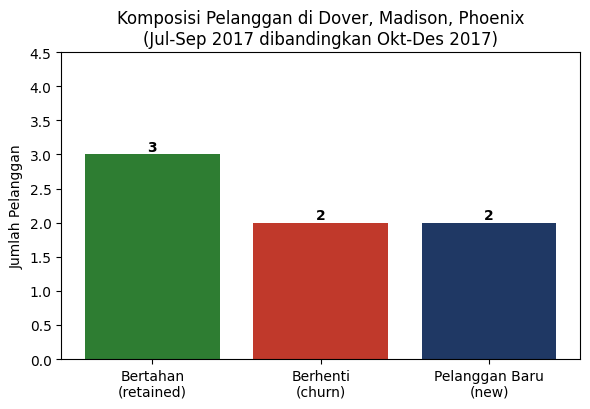

In [6]:
labels = ['Bertahan\n(retained)', 'Berhenti\n(churn)', 'Pelanggan Baru\n(new)']
values = [len(retained), len(churned), len(new_cust)]
colors_bar = ['#2E7D32', '#C0392B', '#1F3864']

plt.figure(figsize=(6, 4.2))
bars = plt.bar(labels, values, color=colors_bar)
for b, v in zip(bars, values):
    plt.text(b.get_x() + b.get_width()/2, v + 0.05, str(v), ha='center', fontweight='bold')
plt.title('Komposisi Pelanggan di Dover, Madison, Phoenix\n(Jul-Sep 2017 dibandingkan Okt-Des 2017)')
plt.ylabel('Jumlah Pelanggan')
plt.ylim(0, max(values) + 1.5)
plt.tight_layout()
plt.savefig('rekomendasi2_churn.png', dpi=120)
plt.show()

### Analysis
Meskipun jumlah total pelanggan aktif di tiga kota ini terlihat sama (5 pelanggan pada kedua periode),
komposisinya ternyata berbeda: hanya **3 pelanggan yang benar-benar bertahan (retained)**, sementara **2
pelanggan lama berhenti total (churn)** dan digantikan oleh **2 pelanggan baru**. Jika hanya melihat angka
total, masalah churn ini akan tersembunyi sepenuhnya &mdash; sama seperti pola "pertumbuhan menutupi masalah"
yang ditemukan di level kota pada hari Senin.

### Insight
Karena basis pelanggannya kecil, setiap pelanggan yang churn berdampak besar secara persentase (40% dari
basis Jul&ndash;Sep 2017). Pendekatan personal (bukan promosi massal) jauh lebih realistis dan efisien untuk
kasus seperti ini, karena jumlah orang yang perlu dihubungi sangat terbatas dan sudah teridentifikasi jelas.

### Recommendation
**Jalankan kampanye reaktivasi personal** (telepon atau email langsung dari tim Customer Success) khusus
kepada 2 pelanggan yang teridentifikasi berhenti bertransaksi, sekaligus program onboarding tambahan untuk
2 pelanggan baru agar tidak mengalami hal yang sama.

**Dampak yang diharapkan:** jika minimal 1 dari 2 pelanggan yang churn berhasil diaktifkan kembali dengan
nilai transaksi serupa periode sebelumnya, kontribusi penurunan dari 3 kota utama (23% dari total kerugian)
berpotensi berkurang secara langsung dalam satu kuartal.

---
## Rekomendasi 3 — Prioritaskan Promosi Pemulihan pada Kategori Perlengkapan Kantor

### Evidence

In [7]:
sub_prev = prev3[prev3['City'].isin(top3)]
sub_last = last3[last3['City'].isin(top3)]

cat_comp = pd.DataFrame({
    'Penjualan_JulSep2017': sub_prev.groupby('Category')['SalesAmount'].sum(),
    'Penjualan_OktDes2017': sub_last.groupby('Category')['SalesAmount'].sum()
})
cat_comp['Selisih'] = cat_comp['Penjualan_OktDes2017'] - cat_comp['Penjualan_JulSep2017']
cat_comp['Persentase_Penurunan'] = cat_comp['Selisih'] / cat_comp['Penjualan_JulSep2017'] * 100
cat_comp = cat_comp.sort_values('Selisih')
cat_comp

,Penjualan_JulSep2017,Penjualan_OktDes2017,Selisih,Persentase_Penurunan
Category,,,,
Office Supplies,"9,260.70",697.11,"-8,563.59",-92.47
Furniture,"7,626.88",832.36,"-6,794.52",-89.09
Technology,"3,190.94",104.75,"-3,086.19",-96.72


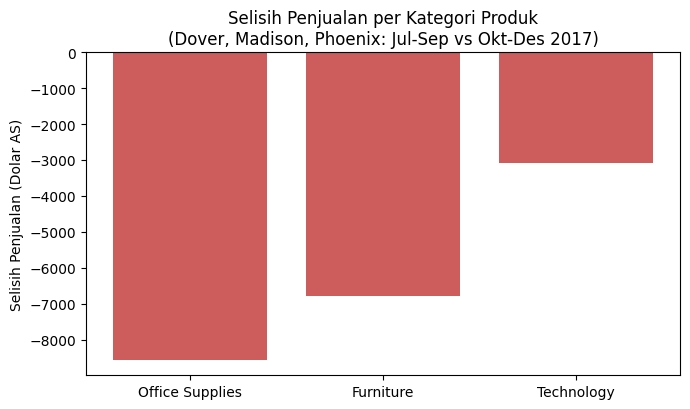

In [8]:
plt.figure(figsize=(7, 4.2))
plt.bar(cat_comp.index, cat_comp['Selisih'], color='indianred')
plt.title('Selisih Penjualan per Kategori Produk\n(Dover, Madison, Phoenix: Jul-Sep vs Okt-Des 2017)')
plt.ylabel('Selisih Penjualan (Dolar AS)')
plt.tight_layout()
plt.savefig('rekomendasi3_kategori.png', dpi=120)
plt.show()

### Analysis
Di tiga kota utama, kategori **Perlengkapan Kantor (Office Supplies)** mengalami penurunan nilai terbesar
(dari sekitar $9.261 menjadi $697), lebih besar secara nilai dibanding Perabot Kantor maupun Teknologi. Ini
konsisten dengan temuan pada Root Cause Analysis (Hari Senin) yang juga menunjukkan kategori ini paling
terdampak secara keseluruhan.

### Insight
Perlengkapan Kantor bukan hanya kategori dengan penurunan terbesar secara keseluruhan (temuan Hari Senin),
tapi juga konsisten menjadi kategori paling terdampak khusus di tiga kota dengan masalah terbesar. Ini
memperkuat bahwa kategori ini adalah titik lemah utama yang perlu ditangani lebih dulu.

### Recommendation
**Prioritaskan promosi pemulihan (misalnya diskon atau bundling) pada kategori Perlengkapan Kantor** di
Dover, Madison, dan Phoenix terlebih dahulu, sebelum kategori lain, karena di sinilah potensi pemulihan
nilai penjualan paling besar.

**Dampak yang diharapkan:** jika penjualan kategori Perlengkapan Kantor di tiga kota ini pulih 50% saja
menuju level Jul&ndash;Sep 2017, akan menyumbang sekitar $4.280 tambahan penjualan pada kuartal berikutnya.

---
## Ringkasan 3 Rekomendasi

| No | Rekomendasi | Bukti Data Utama | Dampak yang Diharapkan |
|---|---|---|---|
| 1 | Prioritaskan 31 kota dengan kontribusi kerugian terbesar | 31 dari 87 kota menyumbang 80% dari total kerugian $80.108,42 | Efisiensi sumber daya, potensi pemulihan hingga ~80% kerugian |
| 2 | Kampanye reaktivasi personal di Dover, Madison, Phoenix | Dari 5 pelanggan Jul-Sep 2017, hanya 3 bertahan; 2 churn total, digantikan 2 pelanggan baru | Mengembalikan sebagian dari 23% kontribusi kerugian 3 kota utama |
| 3 | Prioritaskan promosi kategori Perlengkapan Kantor | Kategori ini turun dari $9.261 menjadi $697 di 3 kota utama | Potensi tambahan ~$4.280 jika pulih 50% |

### Catatan
Semua angka pada notebook ini dihitung langsung dari `SalesInsight_Database.xlsx` dan dapat ditelusuri
ulang dengan menjalankan seluruh sel di atas.